# Chapter 9: Text-to-Image Generation with Latent Diffusion

This chapter covers:

* Conducting forward and reverse diffusion processes in the lower-dimensional space
* Compressing an image into a lower-dimensional space
* Converting low-resolution images into high-resolution ones
* Generating high-resolution images based on text prompts using a latent diffusion model
* Modifying existing images based on text prompts

We have explored diffusion models in depth in chapters 5 to 7. In particular, you have learned how to build and train a model to generate clothing-item images conditioned on labeling information in chapter 6. Text-to-image diffusion models can be viewed as a type of conditional generation as well: the goal is to create images conditional on text prompts. We first train a diffusion model to remove noise from images using the text prompt as a guide. To generate an image, we start with an image composed of pure random noise and iteratively refine it using the trained U-Net denoising model. This requires the diffusion model to effectively incorporate the text description as the conditioning information and generate a coherent image that matches this description.

However, generating images with diffusion models conditional on text prompts comes with a high computational cost: high-resolution images have too many pixels. For example, a three-channel color image with a width and height of 512 has a total of 3x512x512=786,432 pixels. Further, diffusion models require noise to be added and removed from images over many iterations (often 1000 or more), which further increases the computational needs and makes both training and inference inefficient and slow. 

To overcome the challenge, Rombach et al. published a paper in 2022 to propose a latent diffusion model (LDM).  Instead of conducting forward and reverse diffusion processes on high-resolution images, the authors propose conducting the diffusion processes in a lower-dimensional space (i.e., the latent space). Since images in the latent space are much smaller in size, the diffusion processes are much faster. However, this means lower quality of the generated images. To compensate for this, after the LDM is trained, we use a variational autoencoder (VAE) to convert the low-resolution latent images back into high-resolution ones as the final output. A VAE is a generative model composed of an encoder and a decoder. The encoder transforms high-resolution images into compact, lower-dimensional representations, which the decoder then uses to reconstruct the original image. The decoder’s ability to convert low-resolution images into high-resolution output is an essential part of the LDM.

In this chapter, you'll learn how LDMs work. Instead of conducting forward and reverse diffusion processes on high-resolution images of size (3, 512, 512), the LDM in this chapter conducts diffusion processes in a latent space where images have dimensions of (4, 64, 64). This reduces the size of the input to the diffusion model by 48 times since (3×512×512)/(4×64×64)=48. This greatly speeds up the diffusion processes. Once the diffusion model is trained, a text prompt is fed to the model to generate images with a size of (4, 64, 64). These low-resolution images are then fed to a trained VAE, which converts them into high-resolution images of size (3, 512, 512).

LDMs are also excellent image editors. We can use a trained LDM to modify an existing image based on a text prompt. Suppose you have an image of a white horse with snow in the background. If you use the prompt "a white horse walks on a sunny sandy beach" to edit the image, the result will show a similar horse, but the background is now a sunny and sandy beach. When you use the prompt "a zebra walks on a white, snow-covered ground" to modify the image, the snowy background will stay almost the same but the horse will become a zebra (as if you magically put black stripes on the white horse). 

# 1. What is a latent diffusion model?
# 2. Compress and reconstruct images with VAEs
To understand how VAEs compress and then reconstruct images, you’ll first download a pre-trained VAE that we’ll use in our LDM. You'll then use the encoder in the VAE to compress two example high-resolution images to the latent space. After that, you'll use the decoder in the VAE to reconstruct the images. You'll compare the reconstructed images with the original ones and see if any information is lost in the process.

The Python programs in this chapter are based on two excellent GitHub repositories: one by the Computer Vision and Learning research group at Ludwig Maximilian University of Munich (https://github.com/CompVis/latent-diffusion) and one by Umar Jamil (https://github.com/hkproj/pytorch-stable-diffusion). 

## 2.1 Download the pre-trained VAE
First, download the two files vocab.json and merges.txt from Hugging Face https://huggingface.co/stable-diffusion-v1-5/stable-diffusion-v1-5/tree/main/tokenizer
and save them in the files folder on your computer. Then go to another Hugging Face site https://huggingface.co/ogkalu/Illustration-Diffusion/tree/main and download the file hollie-mengert.ckpt and save it in the files folder on your computer. Alternatively, you can run the following code cell to download the three files:

In [1]:
import requests, os

# urls for the files
urls=("https://huggingface.co/ogkalu/Illustration-Diffusion"
    "/resolve/main/hollie-mengert.ckpt?download=true",
    "https://huggingface.co/stable-diffusion-v1-5/"
    "stable-diffusion-v1-5/resolve/main/tokenizer/merges.txt",
    "https://huggingface.co/stable-diffusion-v1-5/"
    "stable-diffusion-v1-5/resolve/main/tokenizer/vocab.json")

files=["files/hollie-mengert.ckpt",
       "files/merges.txt", 
       "files/vocab.json"]

if all(os.path.exists(file) for file in files):
    print("files have already been downloaded")
else:
    print("downloading files")
    for url, file in zip(urls, files):
        fb=requests.get(url)
        with open(file,"wb") as f:
            f.write(fb.content)
    print("download complete")

Run the following code cell to clone Umar Jamil's GitHub repository:

In [2]:
!git clone https://github.com/hkproj/pytorch-stable-diffusion

We'll load the trained VAE as follows:

In [3]:
# access the directory /pytorch-stable-diffusion/sd/
import sys
sys.path.append("pytorch-stable-diffusion/sd")    #A

from model_converter import load_from_standard_weights
from encoder import VAE_Encoder
from decoder import VAE_Decoder
import torch

model_file = "files/hollie-mengert.ckpt"
state_dict = load_from_standard_weights(model_file,
        "cpu")    #B
encoder = VAE_Encoder()
encoder.load_state_dict(state_dict['encoder'],
        strict=True)    #C
decoder = VAE_Decoder()
decoder.load_state_dict(state_dict['decoder'],
        strict=True)    #D

Download the two image files beaver.jpg and dolphin.png from the book's GitHub repository https://github.com/markhliu/txt2img and place them in the /files/ folder on your computer. We'll load the two images and use the pre-trained VAE encoder to compress them to the latent space: 

In [4]:
from PIL import Image
from torchvision import transforms

def center_crop(img):    #A   
    width, height = img.size   
    new=min(width,height)
    left = (width - new)/2
    top = (height - new)/2
    right = (width + new)/2
    bottom = (height + new)/2
    im = img.crop((left, top, right, bottom))
    return im
image1=center_crop(Image.open(
    "files/beaver.jpg")).resize((512,512))    #B
image2=center_crop(Image.open(
    "files/dolphin.png")).resize((512,512))    #C
transform=transforms.ToTensor()
image1=transform(image1)
image2=transform(image2)
print(image1.shape, image2.shape)    #D

torch.Size([3, 512, 512]) torch.Size([3, 512, 512])


In [5]:
# answer to exercise 9.1
image3=center_crop(Image.open(
    "files/bird.png")).resize((512,512))    #B
image4=center_crop(Image.open(
    "files/cat.png")).resize((512,512))    #C
transform=transforms.ToTensor()
image3=transform(image3)
image4=transform(image4)
print(image3.shape, image4.shape)    #D

torch.Size([3, 512, 512]) torch.Size([3, 512, 512])


## 1.2 Encode and Decode Images Using the Pre-Trained VAE
Both images have a size of (3, 512, 512), meaning three color channels, with width and height of 512 pixels. We now compress them to the latent space:

In [6]:
N=torch.distributions.Normal(0, 1)
noise=N.sample(torch.Size([1,4,64,64]))    #A    
latent1=encoder(image1.unsqueeze(0),
    noise)[0]    
latent2=encoder(image2.unsqueeze(0),
    noise)[0]    #B    
print(latent1.shape,latent2.shape)    #C

torch.Size([4, 64, 64]) torch.Size([4, 64, 64])


The latents have sizes (4, 64, 64).

In [7]:
# answer to exercise 9.2
latent3=encoder(image3.unsqueeze(0),
    noise)[0]    
latent4=encoder(image4.unsqueeze(0),
    noise)[0]          
print(latent3.shape,latent4.shape)    

torch.Size([4, 64, 64]) torch.Size([4, 64, 64])


Now, let's compare the original images with the images in the latent space:

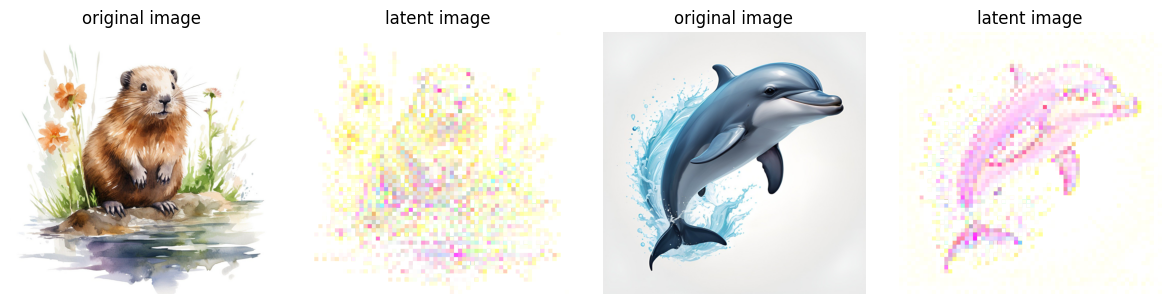

In [8]:
import matplotlib.pyplot as plt
import numpy as np 

imgs=[image1.permute(1,2,0),
  torch.clip(latent1.permute(1,2,0),-1,1).detach().cpu().numpy(
      ).repeat(8, axis=0).repeat(8,axis=1)/2+0.5,
      image2.permute(1,2,0),\
  torch.clip(latent2.permute(1,2,0),-1,1).detach().cpu().numpy(
  ).repeat(8, axis=0).repeat(8,axis=1)/2+0.5]    #A    
plt.figure(figsize=(12,3),dpi=100)
for i in range(4):    #B
    plt.subplot(1,4, i+1)
    plt.imshow(imgs[i])
    if i%2==0:
        plt.title("original image")
    else:
        plt.title("latent image")    #C        
    plt.axis('off')
plt.tight_layout()
plt.show()

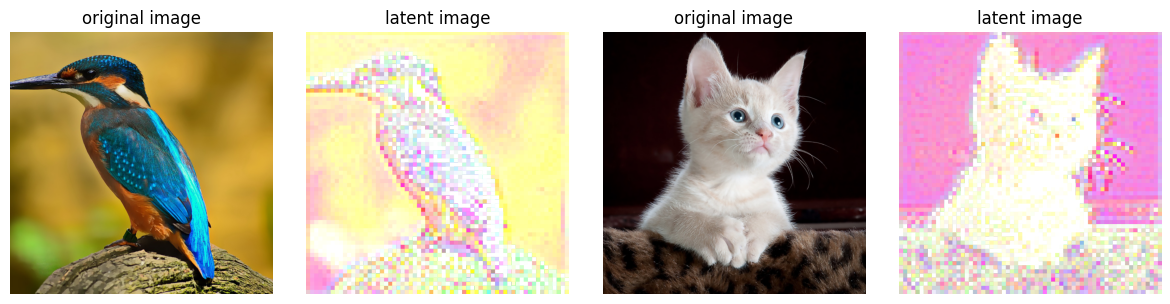

In [9]:
# answer to exercise 9.3
imgs=[image3.permute(1,2,0),
  torch.clip(latent3.permute(1,2,0),-1,1).detach().cpu().numpy(
      ).repeat(8, axis=0).repeat(8,axis=1)/2+0.5,
      image4.permute(1,2,0),\
  torch.clip(latent4.permute(1,2,0),-1,1).detach().cpu().numpy(
  ).repeat(8, axis=0).repeat(8,axis=1)/2+0.5]    #A    
plt.figure(figsize=(12,3),dpi=100)
for i in range(4):    #B
    plt.subplot(1,4, i+1)
    plt.imshow(imgs[i])
    if i%2==0:
        plt.title("original image")
    else:
        plt.title("latent image")    #C        
    plt.axis('off')
plt.tight_layout()
plt.show()

The images in the latent space use only about 2% of the pixels of the original images. However, the plotted latents do have the shape of the original images. 

Next, we use the pretrained VAE decoder to reconstruct the images based on the images in the latent space. 

In [10]:
reconstruct1=decoder(latent1.unsqueeze(0))
reconstruct2=decoder(latent2.unsqueeze(0))
print(reconstruct1.shape,reconstruct2.shape)

torch.Size([1, 3, 512, 512]) torch.Size([1, 3, 512, 512])


We can now compare the originals with the reconstructed images:

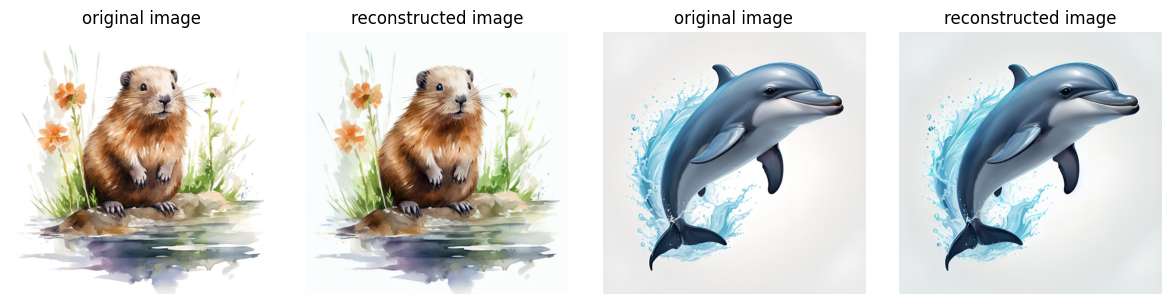

In [11]:
imgs=[image1.permute(1,2,0),
  torch.clip(reconstruct1[0].permute(1,2,0),
    0,1).detach().cpu().numpy(),
    image2.permute(1,2,0),
  torch.clip(reconstruct2[0].permute(1,2,0),
             0,1).detach().cpu().numpy()]    #A    
plt.figure(figsize=(12,3),dpi=100)
for i in range(4):    #B
    plt.subplot(1,4, i+1)
    plt.imshow(imgs[i])
    if i%2==0:
        plt.title("original image")
    else:
        plt.title("reconstructed image")    #C        
    plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# answer to exercise 9.4
reconstruct3=decoder(latent3.unsqueeze(0))
reconstruct4=decoder(latent4.unsqueeze(0))
imgs=[image3.permute(1,2,0),
  torch.clip(reconstruct3[0].permute(1,2,0),
    0,1).detach().cpu().numpy(),
    image4.permute(1,2,0),
  torch.clip(reconstruct4[0].permute(1,2,0),
             0,1).detach().cpu().numpy()]       
plt.figure(figsize=(12,3),dpi=100)
for i in range(4):    
    plt.subplot(1,4, i+1)
    plt.imshow(imgs[i])
    if i%2==0:
        plt.title("original image")
    else:
        plt.title("reconstructed image")           
    plt.axis('off')
plt.tight_layout()
plt.show()

# 3. Text-to-image generation with latent diffusion
## 3.1. Guidance by the CLIP Model


We'll use the pretrained CLIP tokenizer from the transformers library to tokenize the text prompt. Make sure you have the two files tokenizer_vocab.json and tokenizer_merges.txt that you downloaded earlier in the /files/ folder on your computer. 

In [13]:
from transformers import CLIPTokenizer
from clip import CLIP

device="cuda" if torch.cuda.is_available() else "cpu"
decoder.to(device)
tokenizer = CLIPTokenizer("files/vocab.json", 
    merges_file="files/merges.txt")    #A
clip = CLIP().to(device)    #B
clip.load_state_dict(state_dict['clip'], 
    strict=True)    #C

We'll use "A banana riding a motorcycle, wearing sunglasses and a straw hat" as our prompt. There is an optional negative prompt or unconditional prompt, which tells the model not to do in the image. For now, we'll leave the negative prompt empty.

In [14]:
prompt = '''A banana riding a motorcycle, wearing sunglasses and
a straw hat, highly detailed, ultra sharp, cinematic, 
100mm lens, 8k resolution.'''    

uncond_prompt=""    

seed=42
with torch.no_grad():
    generator=torch.Generator(device=device)
    generator.manual_seed(seed)
    cond_tokens=tokenizer.batch_encode_plus(
    [prompt], padding="max_length", max_length=77).input_ids    
    cond_tokens=torch.tensor(cond_tokens,
        dtype=torch.long,device=device)    #A
    print("conditional tokens are\n", cond_tokens)
    cond_context = clip(cond_tokens).to(device)    #B
    uncond_tokens=tokenizer.batch_encode_plus(
        [uncond_prompt], padding="max_length", 
        max_length=77).input_ids    
    uncond_tokens=torch.tensor(uncond_tokens,
       dtype=torch.long,device=device)
    print("unconditional tokens are\n", uncond_tokens)
    uncond_context = clip(uncond_tokens).to(device)    #C    
    clip.to("cpu")
    context=torch.cat([cond_context,uncond_context])    #D

The CLIP tokenizer converts both the prompt and the negative prompt into text embeddings and then concatenates them into one single tensor called $context$. 

## 3.2.	Diffusion Process in the Latent Space

In [15]:
from diffusion import Diffusion
import torch
from ddpm import DDPMSampler

diffusion = Diffusion().to(device)    
diffusion.load_state_dict(state_dict['diffusion'], 
    strict=True)    #A
def get_time_embedding(timestep):    #B
    freqs = torch.pow(10000, -torch.arange(start=0,
                   end=160, dtype=torch.float32) / 160) 
    x = torch.tensor([timestep], 
         dtype=torch.float32)[:, None] * freqs[None]
    return torch.cat([torch.cos(x), torch.sin(x)], dim=-1)
num_reference_steps=50
sampler=DDPMSampler(generator)
sampler.set_inference_timesteps(num_reference_steps)    #C

In [16]:
from tqdm import tqdm
from copy import deepcopy

cfg_scale=8
latent_shape=(1,4,64,64)
noisy_latents=[]    
with torch.no_grad():
    latents=torch.randn(latent_shape,
        generator=generator,device=device)    #A
    timesteps=tqdm(sampler.timesteps)
    for i, timestep in enumerate(timesteps):    #B
        time_embedding=get_time_embedding(timestep).to(device)
        model_input=latents.to(device)
        model_input=model_input.repeat(2,1,1,1)
        model_output=diffusion(model_input,context,time_embedding)
        output_cond,output_uncond=model_output.chunk(2)
        model_output=cfg_scale*(output_cond-output_uncond)+\
            output_uncond    #C
        latents=sampler.step(timestep,latents,model_output)
        if i%10==9:
            noisy_latents.append(deepcopy(latents))    #D
diffusion.to("cpu")  

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [17:41<00:00, 21.24s/it]


We can display the final generated image as follows:

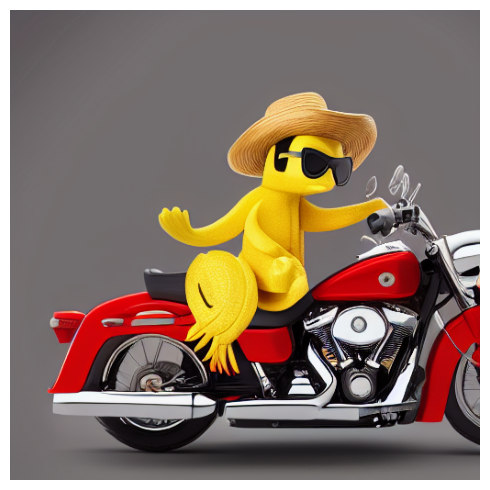

In [17]:
final_latent=noisy_latents[-1]    #A
final_output=decoder(final_latent)    #B
img=torch.clip(final_output[0].permute(1,2,0)/2+0.5,0,1)    #C
plt.figure(dpi=100)
plt.imshow(img.detach().cpu().numpy())    #D
plt.axis("off")
plt.tight_layout()
plt.show()  

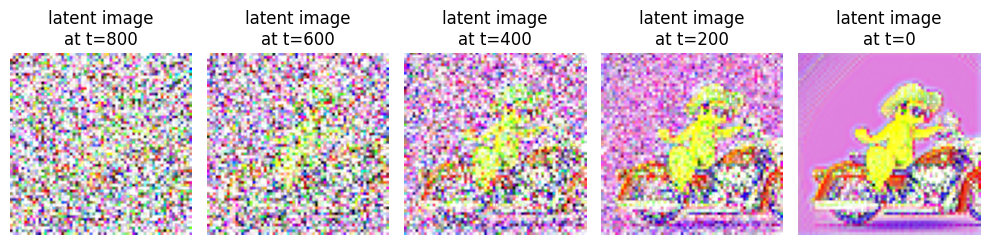

In [18]:
plt.figure(figsize=(10,3),dpi=100)
for i in range(5):    #A
    im=torch.clip(noisy_latents[i][0].permute(1,2,0)/2+0.5,0,1)
    plt.subplot(1,5, i+1)
    plt.imshow(im.detach().cpu().numpy())
    plt.title(f"latent image\nat t={800-i*200}")    #B        
    plt.axis('off')
plt.tight_layout()
plt.show() 

Now, if we were to decode the intermediate latent images to high resolution images, they look like this:

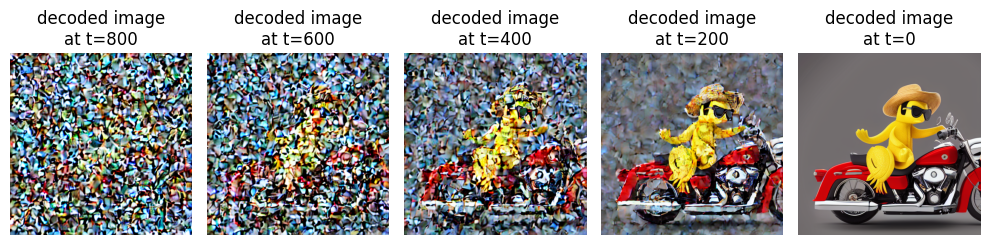

In [19]:
plt.figure(figsize=(10,3),dpi=100)
for i in range(5):
    im=decoder(noisy_latents[i])    #A
    im=torch.clip(im[0].permute(1,2,0)/2+0.5,0,1)
    plt.subplot(1,5, i+1)    #B
    plt.imshow(im.detach().cpu().numpy())
    plt.title(f"decoded image\nat t={800-i*200}")    #C        
    plt.axis('off')
plt.tight_layout()
plt.show() 

The reconstructed image would have looked like the above subplots during the diffusion process. 

# 4.	Modify Existing Images
The latent diffusion model can also modify existing images based on a text prompt. The process is similar to what we have done above, except that the starting point for the diffusion process is not pure noise. It's an existing image, compressed into the latent space. 

In [20]:
import pipeline
import model_loader

models=model_loader.preload_models_from_standard_weights(model_file,
    device)
prompt="A white horse walks on the sunny sandy beach."    #A
uncond_prompt=""
input_image = Image.open("files/horse.png")    #B

output_image = pipeline.generate(    #C
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=0.8,    #D
    do_cfg=True,
    cfg_scale=8,
    sampler_name="ddpm",
    n_inference_steps=50,
    seed=42,
    models=models,
    device=device,
    idle_device="cpu",
    tokenizer=tokenizer,)

100%|██████████| 40/40 [05:46<00:00,  8.66s/it]


We start with a white horse running in the snow. We use the prompt "A white horse walks on the sandy beach under blue sky." The end result is a new image. We still have a white horse resembling the white horse in the original image. However, the background is now a sunny sandy beach instead of a cold white snow-covered field, as you can see from the image below after plotting it with the matplotlib library:

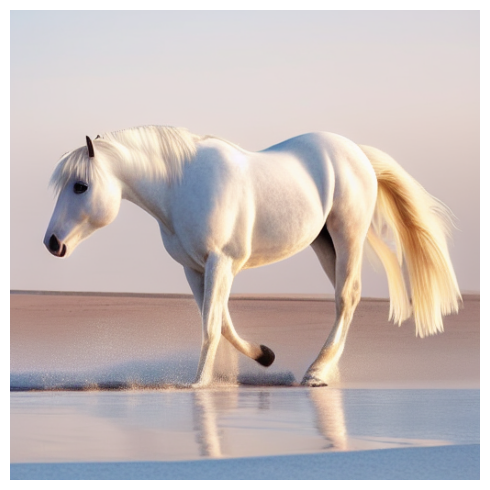

In [21]:
plt.figure(figsize=(5,5),dpi=100)
plt.imshow(output_image)    
plt.axis('off')
plt.tight_layout()
plt.show() 

Let's try another example of modifying existing images. We'll start with the same image of white horse with snow background. However, we change the prompt to "A zebra walks on the white, snow-covered ground."

100%|██████████| 25/25 [03:41<00:00,  8.87s/it]


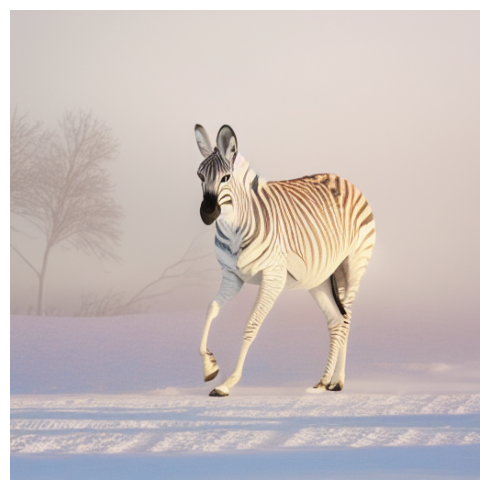

In [22]:
prompt="A zebra walks on the white, snow-covered ground."    #A
output_image = pipeline.generate(    
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=input_image,
    strength=0.5,    #B
    do_cfg=True,
    cfg_scale=8,
    sampler_name="ddpm",
    n_inference_steps=50,
    seed=42,
    models=models,
    device=device,
    idle_device="cpu",
    tokenizer=tokenizer,)
plt.figure(figsize=(5,5),dpi=100)
plt.imshow(output_image)    
plt.axis('off')
plt.tight_layout()
plt.show() 

100%|██████████| 50/50 [07:28<00:00,  8.97s/it]


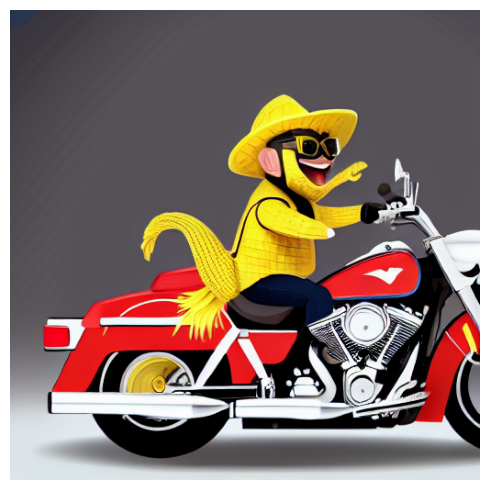

In [23]:
prompt = '''A banana riding a motorcycle, wearing sunglasses and
a straw hat, highly detailed, ultra sharp, cinematic, 
100mm lens, 8k resolution.'''
uncond_prompt=""
output_image12 = pipeline.generate(    #A
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=None,    #B
    strength=1,
    do_cfg=True,
    cfg_scale=12,    #C
    sampler_name="ddpm",
    n_inference_steps=50,
    seed=42,
    models=models,
    device=device,
    idle_device="cpu",
    tokenizer=tokenizer,)
plt.figure(figsize=(5,5),dpi=100)
plt.imshow(output_image12)    #D    
plt.axis('off')
plt.tight_layout()
plt.show()


In [24]:
# answer to exercise 9.6
prompt = '''A banana riding a motorcycle, wearing sunglasses and
a straw hat, highly detailed, ultra sharp, cinematic, 
100mm lens, 8k resolution.'''
uncond_prompt=""
output_image5 = pipeline.generate(    #A
    prompt=prompt,
    uncond_prompt=uncond_prompt,
    input_image=None,    #B
    strength=1,
    do_cfg=True,
    cfg_scale=5,    #C
    sampler_name="ddpm",
    n_inference_steps=50,
    seed=42,
    models=models,
    device=device,
    idle_device="cpu",
    tokenizer=tokenizer,)
plt.figure(figsize=(5,5),dpi=100)
plt.imshow(output_image5)    #D    
plt.axis('off')
plt.tight_layout()
plt.show()